# Prácticas EML1

## Parte 2B

Importamos las librarías necesarias y creamos el entorno para el agente. Además fijamos el valor de todas las semillas para asegurar la reproducibilidad.

In [1]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import time
import random
import matplotlib.pyplot as plt
from collections import defaultdict

# Configurar semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

gym.utils.seeding.np_random(SEED)

# Configuración del entorno FrozenLake
env = gym.make("FrozenLake-v1", is_slippery=True)
env.action_space.seed(SEED)

42

### Método de Monte Carlo (On-Policy vs Off-Policy) en Frozen Lake

Definimos una función que genere un episodio en el entorno siguiendo una política dada. Para ello, inicializamos el estado, ejecutamos las accións según la política hasta que el episodio termina y registramos la secuencia de estado, acción y recompensa.

In [2]:
# Parámetros
num_episodes = int(1e5)

def generate_episode(env, policy):
    """Genera un episodio siguiendo una política dada."""
    episode = []
    state, _ = env.reset()
    done = False
    while not done:
        action = np.random.choice(np.arange(env.action_space.n), p=policy[state])
        next_state, reward, done, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = next_state
    return episode

Creamos la función que implemente el método de Monte Carlo On-policy usando epsilon-greedy. Inicializamos la tabla de valores Q y la política con distribución uniforme, y para cada episodio, generamos una trayectoria con la política actual, calcula el retorno G, actualiza la estimación de Q como el promedio de retornos obtenidos y ajustamos la política usando epsilon-greedy para mejorar la explotación.

In [3]:
# Monte Carlo On-Policy (epsilon-greedy)
def mc_on_policy(env, num_episodes, gamma=1.0, epsilon=0.3):
    """Entrena un agente con Monte Carlo On-Policy usando epsilon-greedy."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns = defaultdict(list)
    policy = np.ones((env.observation_space.n, env.action_space.n)) / env.action_space.n
    episode_lengths = []

    for _ in range(num_episodes):
        episode = generate_episode(env, policy)
        episode_lengths.append(len(episode))
        G = 0
        visited = set()
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward
            if (state, action) not in visited:
                returns[(state, action)].append(G)
                Q[state][action] = np.mean(returns[(state, action)])
                best_action = np.argmax(Q[state])
                policy[state] = epsilon / env.action_space.n
                policy[state][best_action] += 1 - epsilon
                visited.add((state, action))

    return policy, Q, episode_lengths

En este caso creamos la función que implemente el método de Monte Carlo Off-policy con importancia muestral. Inicializamos de nuevo la trabla Q y una política de valores aleatoria, y para cada episodio, se genera una trayectoria con una política exploratoria, se calcula el retorno G, se usa el peso de importancia muestral para corregir la estimación de Q y ajusta la política determinista basada en la mejor acción de Q. Si la accción tomada en el episodio anterior no coincide con la política determinista, se detiene la actualización.

In [4]:
# Monte Carlo Off-Policy (Importancia Muestral)
def mc_off_policy(env, num_episodes, gamma=1.0):
    """Entrena un agente con Monte Carlo Off-Policy usando importancia muestral."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    C = defaultdict(lambda: np.zeros(env.action_space.n))
    target_policy = np.zeros((env.observation_space.n, env.action_space.n))
    episode_lengths = []

    for state in range(env.observation_space.n):
        target_policy[state][np.random.choice(env.action_space.n)] = 1.0

    for _ in range(num_episodes):
        episode = generate_episode(env, np.ones((env.observation_space.n, env.action_space.n)) / env.action_space.n)
        episode_lengths.append(len(episode))
        G = 0
        W = 1.0
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward
            C[state][action] += W
            Q[state][action] += (W / C[state][action]) * (G - Q[state][action])
            target_policy[state] = np.eye(env.action_space.n)[np.argmax(Q[state])]
            if action != np.argmax(target_policy[state]):
                break
            W /= (1 / env.action_space.n)

    return target_policy, Q, episode_lengths

Ahora entrenamos ambos métodos.

In [5]:
%%time

# Entrenar ambos métodos
policy_on, Q_on, episode_lengths_on = mc_on_policy(env, num_episodes)

CPU times: user 16min 4s, sys: 6.02 s, total: 16min 10s
Wall time: 16min 6s


In [6]:
%%time
policy_off, Q_off, episode_lengths_off = mc_off_policy(env, num_episodes)

CPU times: user 34.4 s, sys: 592 ms, total: 35 s
Wall time: 34.6 s


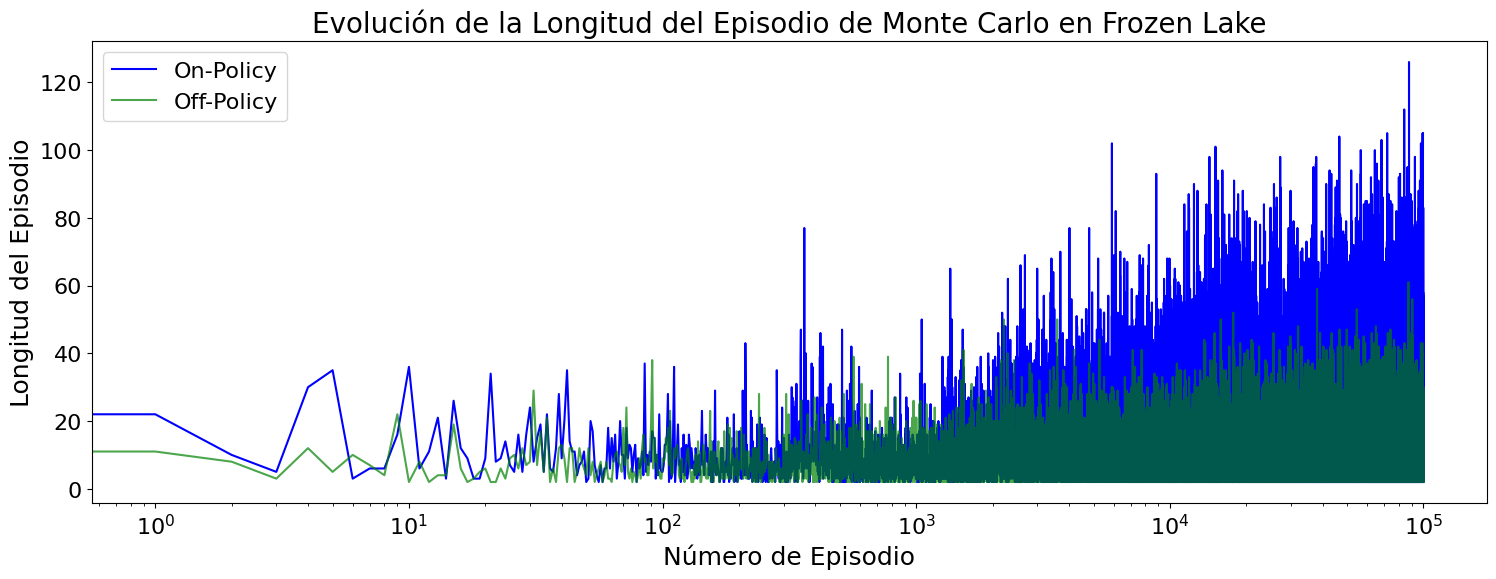

In [7]:
import numpy as np

# Gráfico de comparación de longitud de episodios
timesteps = np.arange(num_episodes)
plt.figure(figsize=(18, 6))
plt.rcParams.update({
    'font.size': 16,       # Tamaño general del texto
    'axes.titlesize': 20,  # Tamaño del título
    'axes.labelsize': 18,  # Tamaño de etiquetas de ejes
    'xtick.labelsize': 16, # Tamaño de etiquetas en el eje X
    'ytick.labelsize': 16, # Tamaño de etiquetas en el eje Y
    'legend.fontsize': 16  # Tamaño de la leyenda
})

plt.plot(timesteps, episode_lengths_on, label="On-Policy", color='blue')
plt.plot(timesteps, episode_lengths_off, label="Off-Policy", color='green', alpha=0.7)
#plt.yscale('log')
plt.xscale('log')
plt.xlabel("Número de Episodio")
plt.ylabel("Longitud del Episodio")
plt.title("Evolución de la Longitud del Episodio de Monte Carlo en Frozen Lake")
plt.legend()
plt.show()

### Método de Diferencias Temporales (SARSA vs Q-Learning) en Frozen Lake

In [8]:
# Parámetros
total_episodes = int(1e5)  # Número total de episodios
gamma = 0.99  # Factor de descuento
alpha = 0.1  # Tasa de aprendizaje
epsilon = 0.1  # Parámetro de exploración epsilon-greedy

Creamos la función para implementar la política epsilon-greedy, que decide la acción a tomar en cada estado.

In [9]:
def epsilon_greedy_policy(Q, state, epsilon, n_actions):
    """Devuelve una acción siguiendo una política epsilon-greedy."""
    if np.random.rand() < epsilon:
        return np.random.choice(n_actions)  # Exploración
    return np.argmax(Q[state])  # Explotación

Creamos una función para el algoritmo SARSA. Inicializamos los valores de Q a 0 y para cada episodio, Seleccionamos una acción usando epsilon-greedy, observamos el siguiente estado y el reward, elegimos la próxima acción y actualizamos la tabla Q con la ecuación de SARS, repitiendo el proceso hasta que el episodio termine.

In [10]:
def sarsa(env, total_episodes, alpha, gamma, epsilon):
    """Entrena un agente con SARSA."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))  # Inicialización de valores Q
    episode_lengths = []

    for _ in range(total_episodes):
        state, _ = env.reset()
        action = epsilon_greedy_policy(Q, state, epsilon, env.action_space.n)
        done = False
        episode_length = 0

        while not done:
            next_state, reward, done, truncated, _ = env.step(action)
            next_action = epsilon_greedy_policy(Q, next_state, epsilon, env.action_space.n)
            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])
            state, action = next_state, next_action
            episode_length += 1

        episode_lengths.append(episode_length)

    return Q, episode_lengths

Ahora implementamos el algoritmo de Q-Learning. En este caso seguimos la misma estructura pero en este caso usamos la ecuación de Q-Learning.

In [11]:
# Q-Learning

def q_learning(env, total_episodes, alpha, gamma, epsilon):
    """Entrena un agente con Q-Learning."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))  # Inicialización de valores Q
    episode_lengths = []

    for _ in range(total_episodes):
        state, _ = env.reset()
        done = False
        episode_length = 0

        while not done:
            action = epsilon_greedy_policy(Q, state, epsilon, env.action_space.n)
            next_state, reward, done, truncated, _ = env.step(action)
            Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])
            state = next_state
            episode_length += 1

        episode_lengths.append(episode_length)

    return Q, episode_lengths

Entrenamos ambas políticas.

In [12]:
%%time

# Entrenar SARSA y Q-Learning
Q_sarsa, episode_lengths_sarsa = sarsa(env, total_episodes, alpha, gamma, epsilon)

CPU times: user 46.6 s, sys: 4 s, total: 50.6 s
Wall time: 48.2 s


In [13]:
%%time
Q_qlearning, episode_lengths_qlearning = q_learning(env, total_episodes, alpha, gamma, epsilon)

CPU times: user 1min 16s, sys: 13.8 s, total: 1min 29s
Wall time: 1min 21s


Definimos la función para evaluar la política aprendida a partir de la tabla Q.

In [14]:
# Evaluar la política obtenida
def evaluate_policy(env, Q, num_episodes=total_episodes):
    """Evalúa una política basada en la función Q aprendida."""
    rewards = []
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(Q[state])
            state, reward, done, truncated, _ = env.step(action)
            total_reward += reward

        rewards.append(total_reward)

    return np.mean(rewards)

In [15]:
# Obtener las puntuaciones medias
score_sarsa = evaluate_policy(env, Q_sarsa)
score_qlearning = evaluate_policy(env, Q_qlearning)

# Mostrar resultados
print(f"Puntuación media SARSA: {score_sarsa}")
print(f"Puntuación media Q-Learning: {score_qlearning}")

Puntuación media SARSA: 0.78342
Puntuación media Q-Learning: 0.82254


Visualizamos los resultados.

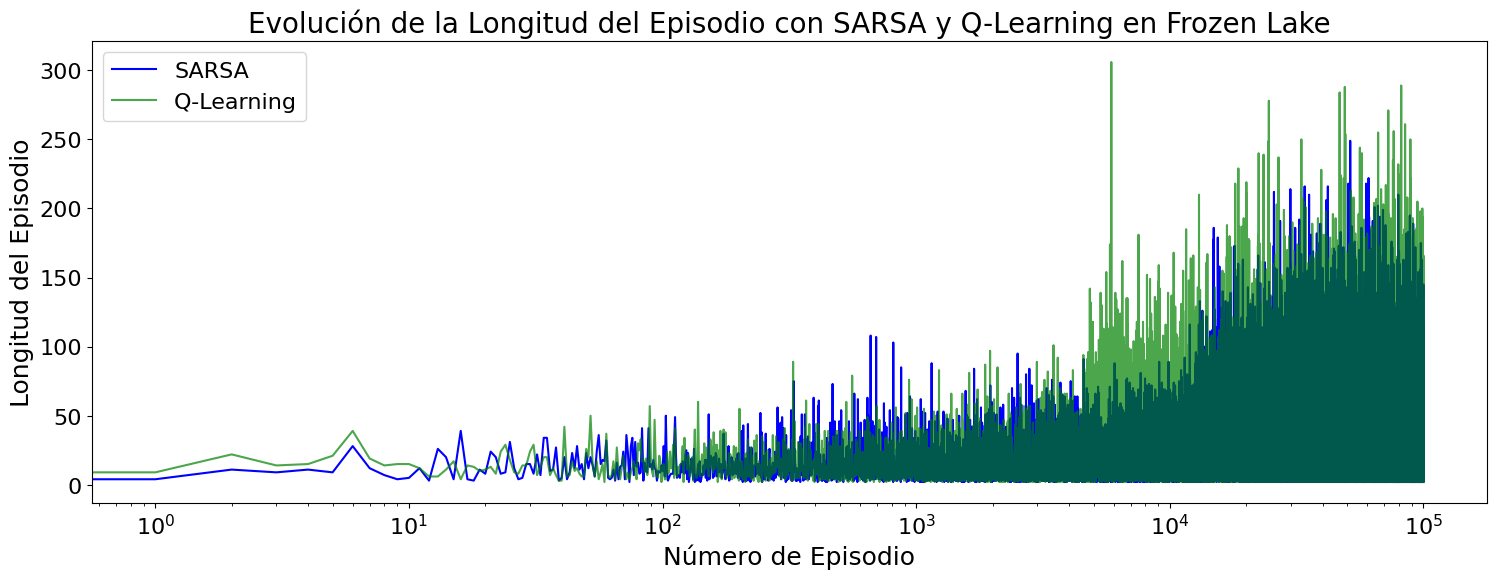

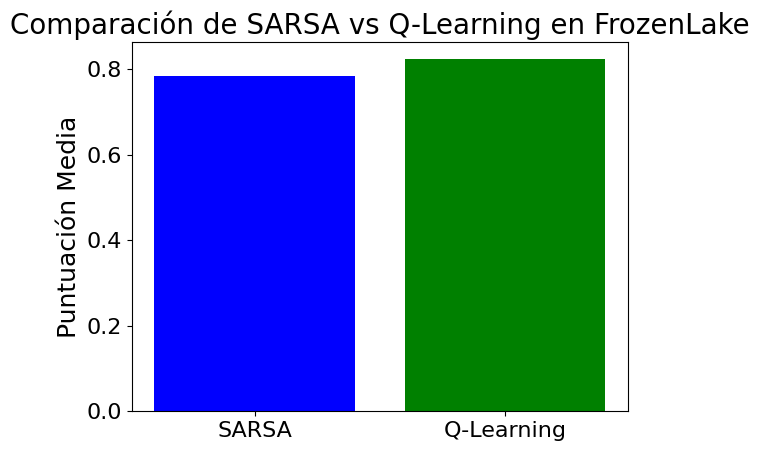

In [16]:
# Gráfico de comparación de longitud de episodios
timesteps = np.arange(total_episodes)
plt.figure(figsize=(18, 6))
plt.rcParams.update({
    'font.size': 16,       # Tamaño general del texto
    'axes.titlesize': 20,  # Tamaño del título
    'axes.labelsize': 18,  # Tamaño de etiquetas de ejes
    'xtick.labelsize': 16, # Tamaño de etiquetas en el eje X
    'ytick.labelsize': 16, # Tamaño de etiquetas en el eje Y
    'legend.fontsize': 16  # Tamaño de la leyenda
})

plt.plot(timesteps, episode_lengths_sarsa, label="SARSA", color='blue')
plt.plot(timesteps, episode_lengths_qlearning, label="Q-Learning", color='green', alpha=0.7)
plt.xscale('log')
plt.xlabel("Número de Episodio")
plt.ylabel("Longitud del Episodio")
plt.title("Evolución de la Longitud del Episodio con SARSA y Q-Learning en Frozen Lake")
plt.legend()
plt.show()

# Gráfico de comparación de puntuaciones
labels = ["SARSA", "Q-Learning"]
scores = [score_sarsa, score_qlearning]
plt.bar(labels, scores, color=['blue', 'green'])
plt.ylabel("Puntuación Media")
plt.title("Comparación de SARSA vs Q-Learning en FrozenLake")
plt.show()

### Control con Aproximaciones(SARSAsemi-gradiente vs Deep Q-Learning)

In [17]:
# Parámetros de entrenamiento
total_episodes = 10000  # Número total de episodios
gamma = 0.99  # Factor de descuento
alpha = 0.1  # Tasa de aprendizaje para SARSA Semi-Gradient
epsilon = 0.1  # Parámetro de exploración epsilon-greedy
lr_dqn = 0.001  # Tasa de aprendizaje para DQN

In [18]:
def one_hot_encoding(state, num_states):
    """Convierte un estado discreto en una representación one-hot."""
    one_hot = np.zeros(num_states)
    one_hot[state] = 1
    return one_hot

In [19]:
def epsilon_greedy_policy(Q, state, epsilon, n_actions):
    """Selecciona una acción usando una política epsilon-greedy."""
    if np.random.rand() < epsilon:
        return np.random.choice(n_actions)  # Exploración
    return np.argmax(Q[state])  # Explotación

In [20]:
# SARSA Semi-Gradient
class SARSA_Agent:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.weights = np.zeros((env.observation_space.n, env.action_space.n))  # Inicialización de pesos

    def select_action(self, state):
        return epsilon_greedy_policy(self.weights, state, self.epsilon, self.env.action_space.n)

    def train(self, num_episodes):
        episode_lengths = []
        episode_rewards = []
        start_time = time.time()

        for episode in range(num_episodes):
            state, _ = self.env.reset()
            action = self.select_action(state)
            done = False
            episode_length = 0
            episode_reward = 0

            while not done:
                next_state, reward, done, truncated, _ = self.env.step(action)
                next_action = self.select_action(next_state)

                td_target = reward + self.gamma * self.weights[next_state][next_action]
                td_error = td_target - self.weights[state][action]
                self.weights[state][action] += self.alpha * td_error

                state, action = next_state, next_action
                episode_length += 1
                episode_reward += reward

            episode_lengths.append(episode_length)
            episode_rewards.append(episode_reward)

            if episode % 1000 == 0:
                elapsed_time = time.time() - start_time
                estimated_total_time = (elapsed_time / (episode + 1)) * num_episodes
                remaining_time = estimated_total_time - elapsed_time
                print(f"SARSA Training: Episodio {episode}/{num_episodes} - Tiempo transcurrido: {elapsed_time:.2f}s - Tiempo restante estimado: {remaining_time:.2f}s")

        return episode_lengths, episode_rewards

In [21]:
# Deep Q-Network (DQN) con PyTorch
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

class DQN_Agent:
    def __init__(self, env, gamma=0.99, epsilon=0.1, lr=0.001):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.lr = lr
        self.model = DQN(env.observation_space.n, env.action_space.n)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.MSELoss()
        self.replay_memory = []
        self.batch_size = 64

    def select_action(self, state):
        state_one_hot = one_hot_encoding(state, self.env.observation_space.n)  # One-hot encoding
        state_tensor = torch.tensor([state_one_hot], dtype=torch.float32)
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()  # Exploración
        with torch.no_grad():
            return torch.argmax(self.model(state_tensor)).item()

    def train(self, num_episodes):
        episode_lengths = []
        episode_rewards = []
        start_time = time.time()

        for episode in range(num_episodes):
            state, _ = self.env.reset()
            done = False
            episode_length = 0
            episode_reward = 0

            while not done:
                action = self.select_action(state)
                next_state, reward, done, truncated, _ = self.env.step(action)
                self.replay_memory.append((state, action, reward, next_state, done))
                episode_reward += reward

                if len(self.replay_memory) > self.batch_size:
                    self.optimize()

                state = next_state
                episode_length += 1

            episode_lengths.append(episode_length)
            episode_rewards.append(episode_reward)

            if episode % 1000 == 0:
                elapsed_time = time.time() - start_time
                estimated_total_time = (elapsed_time / (episode + 1)) * num_episodes
                remaining_time = estimated_total_time - elapsed_time
                print(f"DQN Training: Episodio {episode}/{num_episodes} - Tiempo transcurrido: {elapsed_time:.2f}s - Tiempo restante estimado: {remaining_time:.2f}s")

        return episode_lengths, episode_rewards

    def optimize(self):
        batch = random.sample(self.replay_memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array([one_hot_encoding(s, self.env.observation_space.n) for s in states]), dtype=torch.float32)
        next_states = torch.tensor(np.array([one_hot_encoding(s, self.env.observation_space.n) for s in next_states]), dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

        q_values = self.model(states).gather(1, actions)
        next_q_values = self.model(next_states).max(1, keepdim=True)[0].detach()
        target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        loss = self.criterion(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

In [22]:
%%time
# Entrenar SARSA Semi-Gradient
sarsa_agent = SARSA_Agent(env)
episode_lengths_sarsa, episode_rewards_sarsa = sarsa_agent.train(total_episodes)

SARSA Training: Episodio 0/10000 - Tiempo transcurrido: 0.00s - Tiempo restante estimado: 11.96s
SARSA Training: Episodio 1000/10000 - Tiempo transcurrido: 0.31s - Tiempo restante estimado: 2.77s
SARSA Training: Episodio 2000/10000 - Tiempo transcurrido: 0.66s - Tiempo restante estimado: 2.64s
SARSA Training: Episodio 3000/10000 - Tiempo transcurrido: 0.96s - Tiempo restante estimado: 2.24s
SARSA Training: Episodio 4000/10000 - Tiempo transcurrido: 1.24s - Tiempo restante estimado: 1.86s
SARSA Training: Episodio 5000/10000 - Tiempo transcurrido: 1.63s - Tiempo restante estimado: 1.63s
SARSA Training: Episodio 6000/10000 - Tiempo transcurrido: 2.16s - Tiempo restante estimado: 1.44s
SARSA Training: Episodio 7000/10000 - Tiempo transcurrido: 2.73s - Tiempo restante estimado: 1.17s
SARSA Training: Episodio 8000/10000 - Tiempo transcurrido: 3.28s - Tiempo restante estimado: 0.82s
SARSA Training: Episodio 9000/10000 - Tiempo transcurrido: 3.80s - Tiempo restante estimado: 0.42s
CPU times: u

In [23]:
%%time
# Entrenar SARSA Semi-Gradient y DQN
dqn_agent = DQN_Agent(env)
episode_lengths_dqn, episode_rewards_dqn = dqn_agent.train(total_episodes)

<ipython-input-21-ebe9ca75cb4a>:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  state_tensor = torch.tensor([state_one_hot], dtype=torch.float32)


DQN Training: Episodio 0/10000 - Tiempo transcurrido: 0.07s - Tiempo restante estimado: 651.80s
DQN Training: Episodio 1000/10000 - Tiempo transcurrido: 67.67s - Tiempo restante estimado: 608.35s
DQN Training: Episodio 2000/10000 - Tiempo transcurrido: 141.87s - Tiempo restante estimado: 567.14s
DQN Training: Episodio 3000/10000 - Tiempo transcurrido: 214.97s - Tiempo restante estimado: 501.36s
DQN Training: Episodio 4000/10000 - Tiempo transcurrido: 287.97s - Tiempo restante estimado: 431.78s
DQN Training: Episodio 5000/10000 - Tiempo transcurrido: 363.90s - Tiempo restante estimado: 363.75s
DQN Training: Episodio 6000/10000 - Tiempo transcurrido: 439.52s - Tiempo restante estimado: 292.89s
DQN Training: Episodio 7000/10000 - Tiempo transcurrido: 513.01s - Tiempo restante estimado: 219.76s
DQN Training: Episodio 8000/10000 - Tiempo transcurrido: 586.71s - Tiempo restante estimado: 146.59s
DQN Training: Episodio 9000/10000 - Tiempo transcurrido: 659.13s - Tiempo restante estimado: 73.1

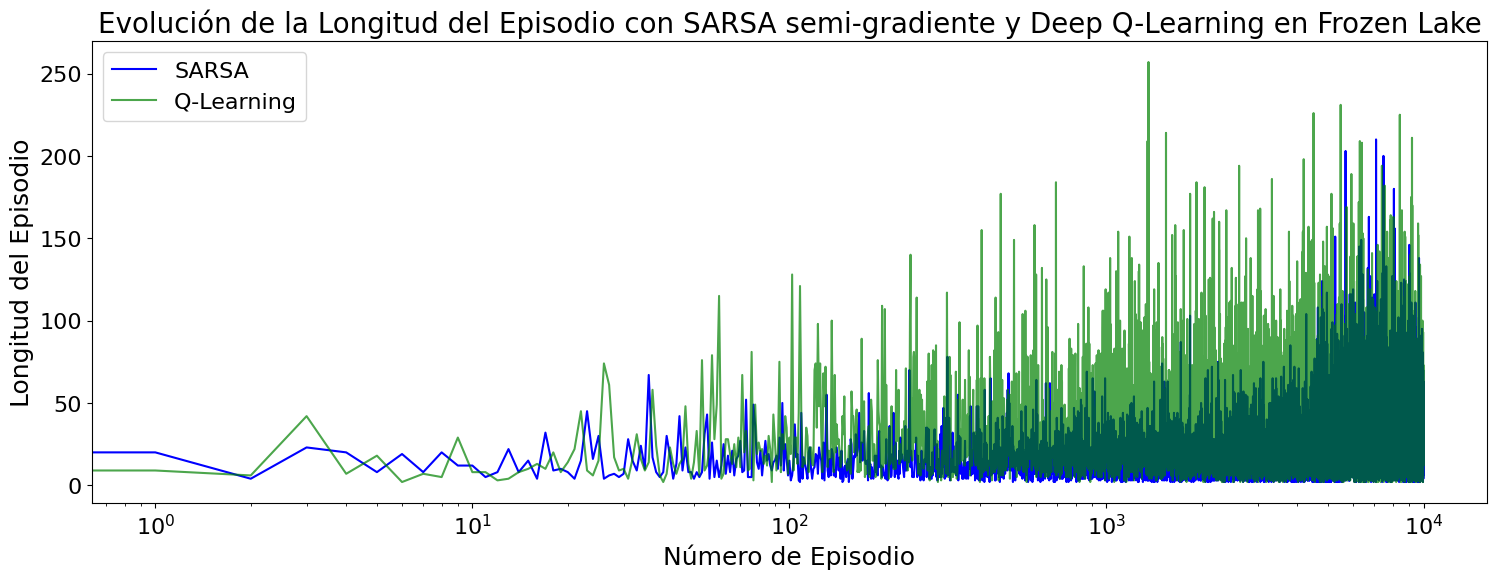

In [24]:
# Gráfico de comparación de longitud de episodios
timesteps = np.arange(total_episodes)
plt.figure(figsize=(18, 6))
plt.rcParams.update({
    'font.size': 16,       # Tamaño general del texto
    'axes.titlesize': 20,  # Tamaño del título
    'axes.labelsize': 18,  # Tamaño de etiquetas de ejes
    'xtick.labelsize': 16, # Tamaño de etiquetas en el eje X
    'ytick.labelsize': 16, # Tamaño de etiquetas en el eje Y
    'legend.fontsize': 16  # Tamaño de la leyenda
})

plt.plot(timesteps, episode_lengths_sarsa, label="SARSA", color='blue')
plt.plot(timesteps, episode_lengths_dqn, label="Q-Learning", color='green', alpha=0.7)
plt.xscale('log')
plt.xlabel("Número de Episodio")
plt.ylabel("Longitud del Episodio")
plt.title("Evolución de la Longitud del Episodio con SARSA semi-gradiente y Deep Q-Learning en Frozen Lake")
plt.legend()
plt.show()

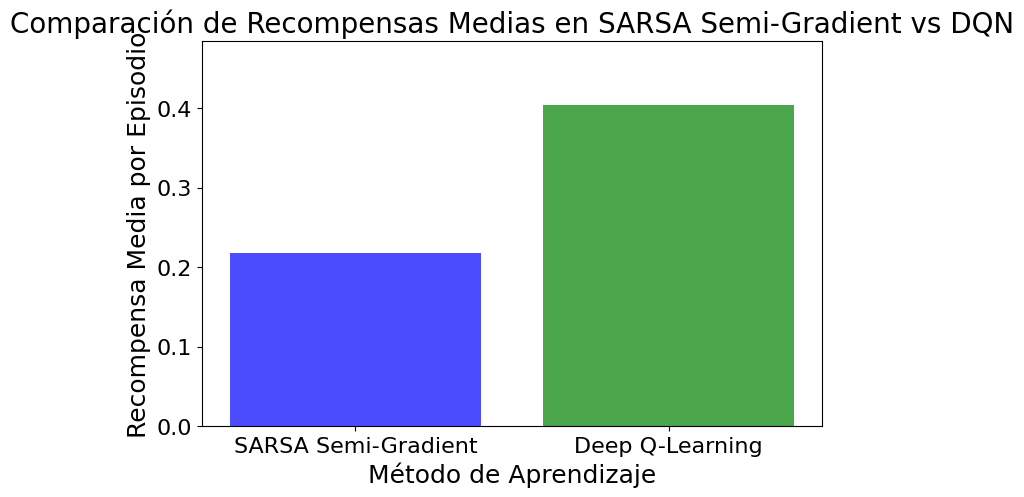

In [25]:
# Calcular recompensas medias
dqn_mean_reward = np.mean(episode_rewards_dqn)
sarsa_mean_reward = np.mean(episode_rewards_sarsa)

# Gráfico de barras comparando las recompensas medias
plt.figure(figsize=(8, 5))
plt.bar(['SARSA Semi-Gradient', 'Deep Q-Learning'], [sarsa_mean_reward, dqn_mean_reward], color=['blue', 'green'], alpha=0.7)
plt.xlabel("Método de Aprendizaje")
plt.ylabel("Recompensa Media por Episodio")
plt.title("Comparación de Recompensas Medias en SARSA Semi-Gradient vs DQN")
plt.ylim(0, max(sarsa_mean_reward, dqn_mean_reward) * 1.2)
plt.show()

### Método de Monte Carlo (On-Policy vs Off-Policy) en Mountain Car

In [26]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import time
import random
import matplotlib.pyplot as plt
from collections import defaultdict

# Configurar semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

gym.utils.seeding.np_random(SEED)

# Configuración del entorno FrozenLake
env = gym.make("MountainCar-v0")
env.action_space.seed(SEED)

42

In [27]:
# Parámetros
num_episodes = 2000  # Más episodios debido a la dificultad del entorno
gamma = 0.99  # Factor de descuento
epsilon = 0.1  # Exploración epsilon-greedy
alpha = 0.1  # Tasa de aprendizaje

In [28]:
# Función para discretizar el estado
def discretize_state(state, bins):
    env_low = env.observation_space.low
    env_high = env.observation_space.high
    state_index = tuple(
        np.digitize(state[i], np.linspace(env_low[i], env_high[i], bins)) - 1
        for i in range(len(state))
    )
    return state_index

In [29]:
# Monte Carlo On-Policy Optimizado (epsilon-greedy)
def mc_on_policy(env, num_episodes, gamma=1.0, epsilon=0.1, bins=20):
    """Entrena un agente con Monte Carlo On-Policy usando epsilon-greedy optimizado."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    policy = defaultdict(lambda: np.ones(env.action_space.n) / env.action_space.n)  # Política inicial aleatoria
    episode_lengths = []
    episode_rewards = []

    start_time = time.time()

    for episode in range(num_episodes):
        state, _ = env.reset()
        state = discretize_state(state, bins)
        episode_data = []
        done = False
        total_reward = 0

        # Generar episodio con np.random.choice para mejorar velocidad
        while not done:
            action = np.random.choice(env.action_space.n, p=policy[state])
            next_state, reward, done, truncated, _ = env.step(action)
            next_state = discretize_state(next_state, bins)
            episode_data.append((state, action, reward))
            state = next_state
            total_reward += reward

        # Actualizar Q y la política con First-Visit Monte Carlo
        G = 0
        visited = set()
        for state, action, reward in reversed(episode_data):
            G = gamma * G + reward
            if (state, action) not in visited:
                returns_sum[(state, action)] += G
                returns_count[(state, action)] += 1
                Q[state][action] = returns_sum[(state, action)] / returns_count[(state, action)]
                best_action = np.argmax(Q[state])
                policy[state] = np.ones(env.action_space.n) * (epsilon / env.action_space.n)
                policy[state][best_action] += (1 - epsilon)
                visited.add((state, action))

        episode_lengths.append(len(episode_data))
        episode_rewards.append(total_reward)

        # Mostrar progreso cada 1000 episodios
        if episode % 10 == 0 and episode > 0:
            elapsed_time = time.time() - start_time
            print(f"Episodio {episode}/{num_episodes} - Tiempo transcurrido: {elapsed_time:.2f}s")

    return policy, Q, episode_lengths, episode_rewards

In [30]:
# Monte Carlo Off-Policy Optimizado (Importancia Muestral)
def mc_off_policy(env, num_episodes, gamma=1.0, bins=20):
    """Entrena un agente con Monte Carlo Off-Policy usando importancia muestral optimizado."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    C = defaultdict(lambda: np.zeros(env.action_space.n))
    target_policy = np.zeros((bins, bins, env.action_space.n))
    episode_lengths = []
    episode_rewards = []

    for state_x in range(bins):
        for state_v in range(bins):
            target_policy[state_x, state_v, np.random.choice(env.action_space.n)] = 1.0

    start_time = time.time()

    for episode in range(num_episodes):
        state, _ = env.reset()
        state = discretize_state(state, bins)
        episode = []
        done = False
        total_reward = 0

        while not done:
            action = np.random.choice(env.action_space.n)  # Exploración uniforme
            next_state, reward, done, truncated, _ = env.step(action)
            next_state = discretize_state(next_state, bins)
            episode.append((state, action, reward))
            state = next_state
            total_reward += reward

        G = 0
        W = 1.0
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward
            C[state][action] += W
            Q[state][action] += (W / C[state][action]) * (G - Q[state][action])
            target_policy[state] = np.eye(env.action_space.n)[np.argmax(Q[state])]
            if action != np.argmax(target_policy[state]):
                break
            W /= (1 / env.action_space.n)

        episode_lengths.append(len(episode))
        episode_rewards.append(total_reward)

        if episode % 1000 == 0 and episode > 0:
            elapsed_time = time.time() - start_time
            print(f"Episodio {episode}/{num_episodes} - Tiempo transcurrido: {elapsed_time:.2f}s")

    return target_policy, Q, episode_lengths, episode_rewards

In [31]:
%%time
#policy_on, Q_on, episode_lengths_on, episode_rewards_on = mc_on_policy(env, total_episodes)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.25 µs


In [32]:
%%time
#policy_off, Q_off, episode_lengths_off = mc_off_policy(env, num_episodes//2)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.01 µs


Una hora de entrenamiento

In [33]:
# Gráfico de comparación de longitud de episodios
#timesteps = np.arange(num_episodes//2)
#plt.figure(figsize=(12, 6))
#plt.plot(timesteps, episode_lengths_on, label="On-Policy", color='blue')
#plt.plot(timesteps, episode_lengths_off, label="Off-Policy", color='green', alpha=0.5)
#plt.yscale('log')
#plt.xlabel("Número de Episodio")
#plt.ylabel("Longitud del Episodio")
#plt.title("Evolución de la Longitud del Episodio en Monte Carlo On-Policy vs Off-Policy")
#plt.legend()
#plt.show()

### Método de Diferencias Temporales (SARSA vs Q-Learning) en Mountain Car

In [34]:
# Parámetros
total_episodes = 10000  # Número total de episodios
gamma = 0.99  # Factor de descuento
alpha = 0.1  # Tasa de aprendizaje
epsilon = 0.1  # Parámetro de exploración epsilon-greedy
bins = 20  # Discretización del espacio de estados

Definimos una función para discretizar los estados

In [35]:
def discretize_state(state, bins):
    """Convierte el estado continuo en un estado discreto usando bins."""
    env_low = env.observation_space.low
    env_high = env.observation_space.high
    state_index = tuple(
        np.digitize(state[i], np.linspace(env_low[i], env_high[i], bins)) - 1
        for i in range(len(state))
    )
    return state_index

Creamos la función para implementar la política epsilon-greedy, que decide la acción a tomar en cada estado.

In [36]:
def epsilon_greedy_policy(Q, state, epsilon, n_actions):
    """Selecciona una acción usando una política epsilon-greedy."""
    if np.random.rand() < epsilon:
        return np.random.choice(n_actions)  # Exploración
    return np.argmax(Q[state])  # Explotación

Creamos una función para el algoritmo SARSA. Inicializamos los valores de Q a 0 y para cada episodio, Seleccionamos una acción usando epsilon-greedy, observamos el siguiente estado y el reward, elegimos la próxima acción y actualizamos la tabla Q con la ecuación de SARS, repitiendo el proceso hasta que el episodio termine.

In [37]:
def train_sarsa(env, total_episodes, alpha, gamma, epsilon, bins):
    """Entrena un agente con SARSA en el entorno MountainCar."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))  # Inicialización de valores Q
    episode_lengths = []
    start_time = time.time()

    for episode in range(total_episodes):
        state, _ = env.reset()
        state = discretize_state(state, bins)
        action = epsilon_greedy_policy(Q, state, epsilon, env.action_space.n)
        done = False
        episode_length = 0

        while not done:
            next_state, reward, done, truncated, _ = env.step(action)
            next_state = discretize_state(next_state, bins)
            next_action = epsilon_greedy_policy(Q, next_state, epsilon, env.action_space.n)

            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])
            state, action = next_state, next_action
            episode_length += 1

        episode_lengths.append(episode_length)

        if episode % 1000 == 0:
            elapsed_time = time.time() - start_time
            estimated_total_time = (elapsed_time / (episode + 1)) * total_episodes
            remaining_time = estimated_total_time - elapsed_time
            print(f"SARSA Training: Episodio {episode}/{total_episodes} - Tiempo transcurrido: {elapsed_time:.2f}s - Tiempo restante estimado: {remaining_time:.2f}s")

    return Q, episode_lengths

Ahora implementamos el algoritmo de Q-Learning. En este caso seguimos la misma estructura pero en este caso usamos la ecuación de Q-Learning.

In [38]:
def train_qlearning(env, total_episodes, alpha, gamma, epsilon, bins):
    """Entrena un agente con Q-Learning en el entorno MountainCar."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))  # Inicialización de valores Q
    episode_lengths = []
    start_time = time.time()

    for episode in range(total_episodes):
        state, _ = env.reset()
        state = discretize_state(state, bins)
        done = False
        episode_length = 0

        while not done:
            action = epsilon_greedy_policy(Q, state, epsilon, env.action_space.n)
            next_state, reward, done, truncated, _ = env.step(action)
            next_state = discretize_state(next_state, bins)

            Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])
            state = next_state
            episode_length += 1

        episode_lengths.append(episode_length)

        if episode % 1000 == 0:
            elapsed_time = time.time() - start_time
            estimated_total_time = (elapsed_time / (episode + 1)) * total_episodes
            remaining_time = estimated_total_time - elapsed_time
            print(f"Q-Learning Training: Episodio {episode}/{total_episodes} - Tiempo transcurrido: {elapsed_time:.2f}s - Tiempo restante estimado: {remaining_time:.2f}s")

    return Q, episode_lengths

Entrenamos ambas políticas.

In [39]:
%%time
# Entrenar SARSA
Q_sarsa, episode_lengths_sarsa = train_sarsa(env, total_episodes, alpha, gamma, epsilon, bins)

SARSA Training: Episodio 0/10000 - Tiempo transcurrido: 0.93s - Tiempo restante estimado: 9278.34s
SARSA Training: Episodio 1000/10000 - Tiempo transcurrido: 32.47s - Tiempo restante estimado: 291.93s
SARSA Training: Episodio 2000/10000 - Tiempo transcurrido: 50.77s - Tiempo restante estimado: 202.96s
SARSA Training: Episodio 3000/10000 - Tiempo transcurrido: 66.98s - Tiempo restante estimado: 156.21s
SARSA Training: Episodio 4000/10000 - Tiempo transcurrido: 82.26s - Tiempo restante estimado: 123.34s
SARSA Training: Episodio 5000/10000 - Tiempo transcurrido: 96.98s - Tiempo restante estimado: 96.94s
SARSA Training: Episodio 6000/10000 - Tiempo transcurrido: 111.31s - Tiempo restante estimado: 74.17s
SARSA Training: Episodio 7000/10000 - Tiempo transcurrido: 127.76s - Tiempo restante estimado: 54.73s
SARSA Training: Episodio 8000/10000 - Tiempo transcurrido: 144.07s - Tiempo restante estimado: 35.99s
SARSA Training: Episodio 9000/10000 - Tiempo transcurrido: 158.63s - Tiempo restante e

In [40]:
%%time
# Entrenar Q-Learning
Q_qlearning, episode_lengths_qlearning = train_qlearning(env, total_episodes, alpha, gamma, epsilon, bins)

Q-Learning Training: Episodio 0/10000 - Tiempo transcurrido: 1.27s - Tiempo restante estimado: 12731.26s
Q-Learning Training: Episodio 1000/10000 - Tiempo transcurrido: 43.84s - Tiempo restante estimado: 394.10s
Q-Learning Training: Episodio 2000/10000 - Tiempo transcurrido: 65.55s - Tiempo restante estimado: 262.03s
Q-Learning Training: Episodio 3000/10000 - Tiempo transcurrido: 85.62s - Tiempo restante estimado: 199.69s
Q-Learning Training: Episodio 4000/10000 - Tiempo transcurrido: 105.51s - Tiempo restante estimado: 158.19s
Q-Learning Training: Episodio 5000/10000 - Tiempo transcurrido: 125.59s - Tiempo restante estimado: 125.54s
Q-Learning Training: Episodio 6000/10000 - Tiempo transcurrido: 144.20s - Tiempo restante estimado: 96.09s
Q-Learning Training: Episodio 7000/10000 - Tiempo transcurrido: 163.64s - Tiempo restante estimado: 70.10s
Q-Learning Training: Episodio 8000/10000 - Tiempo transcurrido: 185.28s - Tiempo restante estimado: 46.29s
Q-Learning Training: Episodio 9000/10

Visualizamos los resultados.

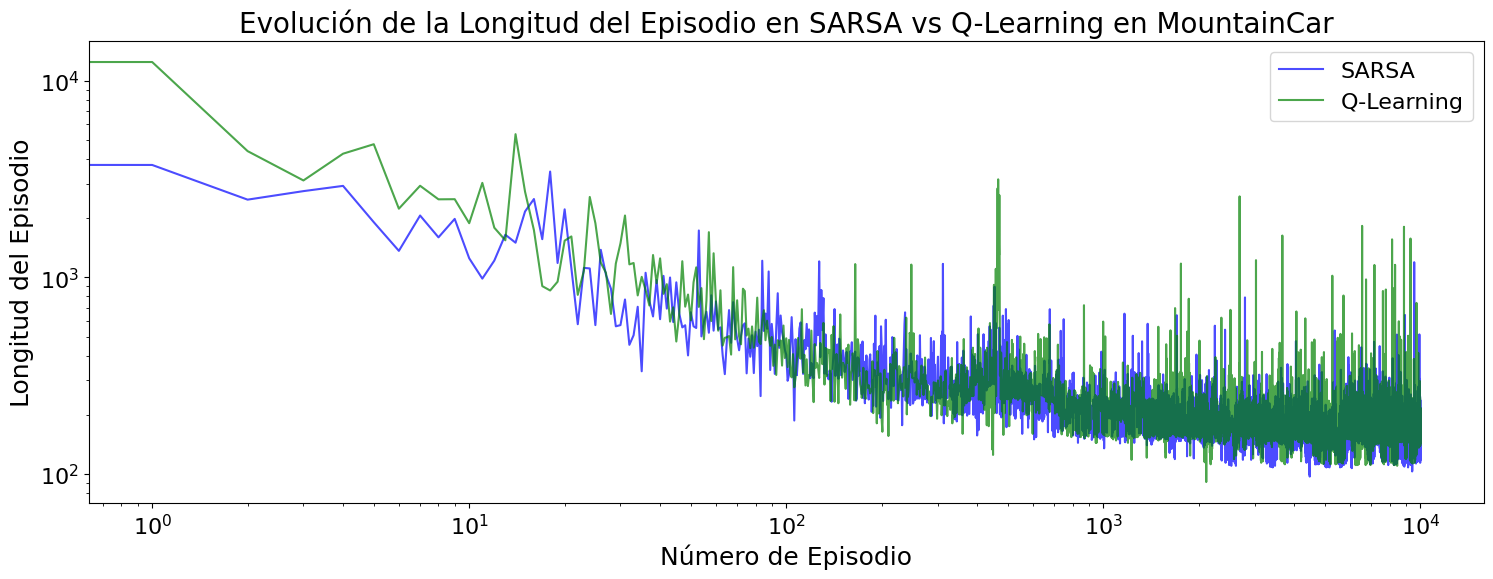

In [41]:
# Gráfico de comparación de longitud de episodios
timesteps = np.arange(total_episodes)
plt.figure(figsize=(18, 6))
plt.rcParams.update({
    'font.size': 16,       # Tamaño general del texto
    'axes.titlesize': 20,  # Tamaño del título
    'axes.labelsize': 18,  # Tamaño de etiquetas de ejes
    'xtick.labelsize': 16, # Tamaño de etiquetas en el eje X
    'ytick.labelsize': 16, # Tamaño de etiquetas en el eje Y
    'legend.fontsize': 16  # Tamaño de la leyenda
})

plt.plot(timesteps, episode_lengths_sarsa, label="SARSA", color='blue', alpha=0.7)
plt.plot(timesteps, episode_lengths_qlearning, label="Q-Learning", color='green', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Número de Episodio")
plt.ylabel("Longitud del Episodio")
plt.title("Evolución de la Longitud del Episodio en SARSA vs Q-Learning en MountainCar")
plt.legend()
plt.show()

### Método Control de Aproximaciones (SARSA semi-gradient vs Deep Q-Learning) en Mountain Car

In [42]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
from collections import deque, defaultdict
from itertools import count
import time

# Configurar el dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Fijar la semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

gym.utils.seeding.np_random(SEED)

# Configuración del entorno MountainCar
env = gym.make("MountainCar-v0")
env.action_space.seed(SEED)

Usando dispositivo: cuda


42

In [43]:
# Parámetros
total_episodes = 10000  # Mayor número de episodios debido a la dificultad del entorno
gamma = 0.99  # Factor de descuento
alpha = 0.1  # Tasa de aprendizaje para SARSA
epsilon = 0.1  # Exploración epsilon-greedy

In [44]:
def discretize_state(state, bins):
    """Convierte el estado continuo en un estado discreto usando bins."""
    env_low = env.observation_space.low
    env_high = env.observation_space.high
    env_bins = bins
    state_index = tuple(
        np.digitize(state[i], np.linspace(env_low[i], env_high[i], env_bins)) - 1
        for i in range(len(state))
    )
    return state_index

In [45]:
import numpy as np
import time

class SARSA_Agent:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1, bins=20):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.bins = bins
        self.weights = np.zeros((bins, bins, env.action_space.n))  # Pesos de la función de aproximación

    def discretize_state(self, state):
        """ Convierte un estado continuo en un índice discreto basado en bins. """
        state_min = self.env.observation_space.low
        state_max = self.env.observation_space.high
        state_scaled = (state - state_min) / (state_max - state_min)  # Escalar entre 0 y 1
        state_discrete = np.clip((state_scaled * self.bins).astype(int), 0, self.bins - 1)
        return tuple(state_discrete)  # Convertir a tupla de índices

    def select_action(self, state):
        """ Selecciona una acción usando epsilon-greedy. """
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.env.action_space.n)  # Exploración
        return np.argmax(self.weights[state])  # Explotación basada en los pesos aprendidos

    def train(self, num_episodes):
        """ Entrena el agente usando SARSA con actualización semi-gradient. """
        episode_lengths = []
        start_time = time.time()

        for episode in range(num_episodes):
            state = self.env.reset()
            if isinstance(state, tuple):  # Para entornos que devuelven (state, info)
                state = state[0]
            state = self.discretize_state(state)
            action = self.select_action(state)
            done = False
            episode_length = 0

            while not done:
                next_state, reward, terminated, truncated, info = env.step(action)
                next_state, reward, done, _, _ = self.env.step(action)
                next_state = self.discretize_state(next_state)
                next_action = self.select_action(next_state)

                # SARSA Semi-Gradient Update
                td_target = reward + self.gamma * self.weights[next_state][next_action] * (not done)
                td_error = td_target - self.weights[state][action]
                self.weights[state][action] += self.alpha * td_error

                state, action = next_state, next_action
                episode_length += 1

            episode_lengths.append(episode_length)
            if episode % 1000 == 0:
                elapsed_time = time.time() - start_time
                estimated_total_time = (elapsed_time / (episode + 1)) * num_episodes
                remaining_time = estimated_total_time - elapsed_time
                print(f"SARSA Training: Episodio {episode}/{num_episodes} - Tiempo transcurrido: {elapsed_time:.2f}s - Tiempo restante estimado: {remaining_time:.2f}s")

        return episode_lengths

In [46]:
# Parámetros
total_episodes_dqn = 1000  # Reducido para pruebas más rápidas
gamma = 0.99  # Factor de descuento
alpha = 0.1  # Tasa de aprendizaje para SARSA
epsilon = 0.1  # Exploraciónpsilon-greedy
batch_size = 64
lr = 0.0005  # Reducido para mejorar estabilidad del aprendizaje
target_update = 10  # Actualización de la red objetivo cada ciertos pasos

In [47]:
def discretize_state(state, bins):
    """Convierte el estado continuo en un estado discreto usando bins."""
    env_low = env.observation_space.low
    env_high = env.observation_space.high
    env_bins = bins
    state_index = tuple(
        np.digitize(state[i], np.linspace(env_low[i], env_high[i], env_bins)) - 1
        for i in range(len(state))
    )
    return state_index

In [48]:
# Deep Q-Network (DQN) con PyTorch
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
#        self.fc2 = nn.Linear(32, 32)
        self.fc2 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
#        x = torch.relu(self.fc2(x))
        return self.fc2(x)

class DQN_Agent:
    def __init__(self, env, gamma=0.99, epsilon=0.1, lr=0.0005):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.lr = lr
        self.batch_size = batch_size
        self.model = DQN(env.observation_space.shape[0], env.action_space.n).to(device)
        self.target_model = DQN(env.observation_space.shape[0], env.action_space.n).to(device)
        self.target_model.load_state_dict(self.model.state_dict())
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.MSELoss()
        self.replay_memory = deque(maxlen=10000)
        self.target_update_counter = 0

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()  # Exploración
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            return torch.argmax(self.model(state_tensor)).item()

    def train(self, num_episodes):
        episode_lengths = []
        episode_rewards = []
        start_time = time.time()

        for episode in range(num_episodes):
            state, _ = self.env.reset()
            done = False
            episode_length = 0
            episode_reward = 0

            while not done:
                action = self.select_action(state)
                next_state, reward, done, truncated, _ = self.env.step(action)
                self.replay_memory.append((np.array(state, dtype=np.float32), action, reward, np.array(next_state, dtype=np.float32), done))
                episode_reward += reward

                if len(self.replay_memory) > self.batch_size:
                    self.optimize()

                state = next_state
                episode_length += 1

            episode_lengths.append(episode_length)
            episode_rewards.append(episode_reward)

            if episode % target_update == 0:
                self.target_model.load_state_dict(self.model.state_dict())

            if episode % 50 == 0:
                elapsed_time = time.time() - start_time
                estimated_total_time = (elapsed_time / (episode + 1)) * num_episodes
                remaining_time = estimated_total_time - elapsed_time
                print(f"DQN Training: Episodio {episode}/{num_episodes} - Tiempo transcurrido: {elapsed_time:.2f}s - Tiempo restante estimado: {remaining_time:.2f}s")

        return episode_lengths, episode_rewards

    def optimize(self):
        batch = random.sample(self.replay_memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device)

        q_values = self.model(states).gather(1, actions)
        next_q_values = self.target_model(next_states).max(1, keepdim=True)[0].detach()
        target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        loss = self.criterion(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

In [49]:
%%time
# Entrenar SARSA Semi-Gradient
sarsa_agent = SARSA_Agent(env)
episode_lengths_sarsa = sarsa_agent.train(total_episodes)

SARSA Training: Episodio 0/10000 - Tiempo transcurrido: 0.20s - Tiempo restante estimado: 1955.39s
SARSA Training: Episodio 1000/10000 - Tiempo transcurrido: 10.30s - Tiempo restante estimado: 92.63s
SARSA Training: Episodio 2000/10000 - Tiempo transcurrido: 15.53s - Tiempo restante estimado: 62.09s
SARSA Training: Episodio 3000/10000 - Tiempo transcurrido: 20.72s - Tiempo restante estimado: 48.33s
SARSA Training: Episodio 4000/10000 - Tiempo transcurrido: 25.54s - Tiempo restante estimado: 38.29s
SARSA Training: Episodio 5000/10000 - Tiempo transcurrido: 29.96s - Tiempo restante estimado: 29.95s
SARSA Training: Episodio 6000/10000 - Tiempo transcurrido: 34.20s - Tiempo restante estimado: 22.79s
SARSA Training: Episodio 7000/10000 - Tiempo transcurrido: 38.66s - Tiempo restante estimado: 16.56s
SARSA Training: Episodio 8000/10000 - Tiempo transcurrido: 43.17s - Tiempo restante estimado: 10.79s
SARSA Training: Episodio 9000/10000 - Tiempo transcurrido: 47.39s - Tiempo restante estimado:

In [50]:
%%time
# Entrenar Deep Q-Learning
dqn_agent = DQN_Agent(env)
episode_lengths_dqn, episode_rewards_dqn = dqn_agent.train(total_episodes_dqn)

DQN Training: Episodio 0/1000 - Tiempo transcurrido: 3.90s - Tiempo restante estimado: 3891.11s
DQN Training: Episodio 50/1000 - Tiempo transcurrido: 46.06s - Tiempo restante estimado: 857.14s
DQN Training: Episodio 100/1000 - Tiempo transcurrido: 84.30s - Tiempo restante estimado: 750.33s
DQN Training: Episodio 150/1000 - Tiempo transcurrido: 115.95s - Tiempo restante estimado: 651.95s
DQN Training: Episodio 200/1000 - Tiempo transcurrido: 142.39s - Tiempo restante estimado: 566.01s
DQN Training: Episodio 250/1000 - Tiempo transcurrido: 164.63s - Tiempo restante estimado: 491.27s
DQN Training: Episodio 300/1000 - Tiempo transcurrido: 185.22s - Tiempo restante estimado: 430.13s
DQN Training: Episodio 350/1000 - Tiempo transcurrido: 204.26s - Tiempo restante estimado: 377.67s
DQN Training: Episodio 400/1000 - Tiempo transcurrido: 220.49s - Tiempo restante estimado: 329.37s
DQN Training: Episodio 450/1000 - Tiempo transcurrido: 236.07s - Tiempo restante estimado: 287.37s
DQN Training: Ep

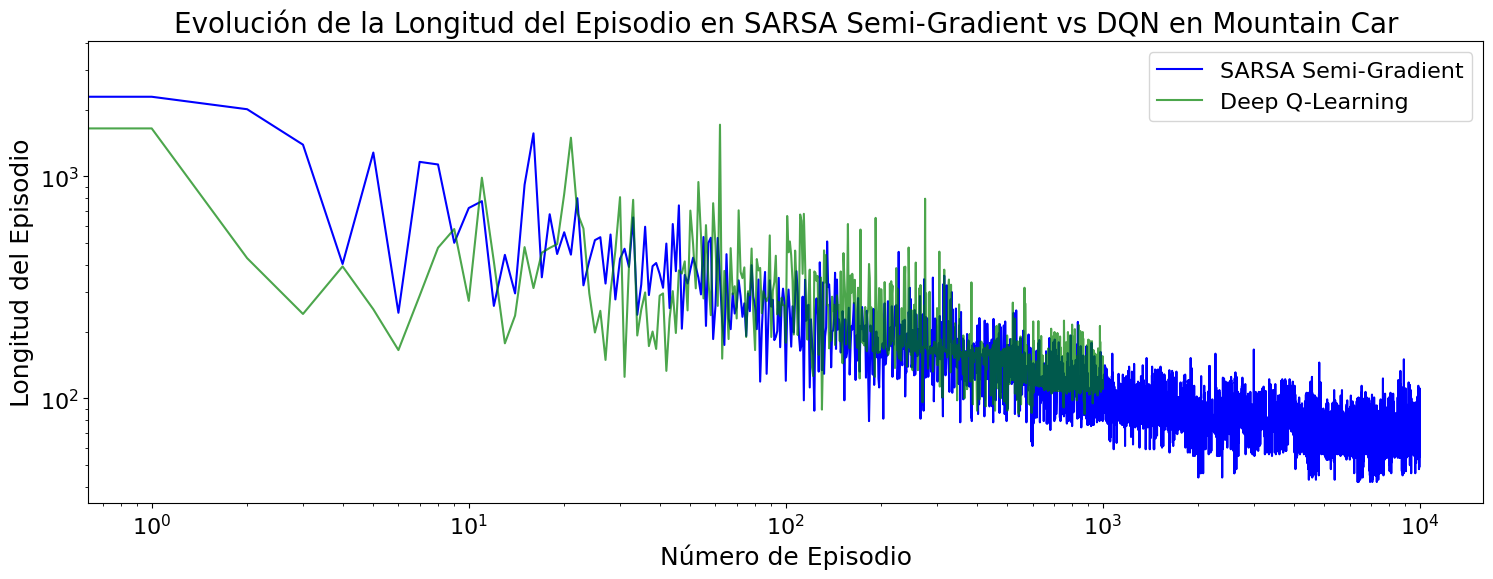

In [51]:
# Gráfico de comparación de longitud de episodios
timesteps = np.arange(total_episodes)
timesteps2 = np.arange(total_episodes_dqn)
plt.figure(figsize=(18, 6))
plt.plot(timesteps, episode_lengths_sarsa, label="SARSA Semi-Gradient", color='blue')
plt.plot(timesteps2, episode_lengths_dqn, label="Deep Q-Learning", color='green', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Número de Episodio")
plt.ylabel("Longitud del Episodio")
plt.title("Evolución de la Longitud del Episodio en SARSA Semi-Gradient vs DQN en Mountain Car")
plt.legend()
plt.show()